In [14]:
!pip install networkx
!pip install graphviz
!pip install pyvis

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [15]:
from michigrad.engine import Value
from michigrad.nn import Neuron, Layer, MLP
from michigrad.visualize import show_graph, show_graph_interactive
import numpy as np

In [16]:
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

In [17]:
Model = MLP(2, [2])

In [18]:
xs = [[0, 0], [0, 1], [1, 0], [1, 1]]
ys = [0, 1, 1, 0]

In [19]:
#Forward
yhat = [Model(x)[0] for x in xs]
#Loss
loss = sum([(y - yh)**2 for y, yh in zip(ys, yhat)])/4
print(loss)

Value(data=0.36338144519746884, grad=0, name=)


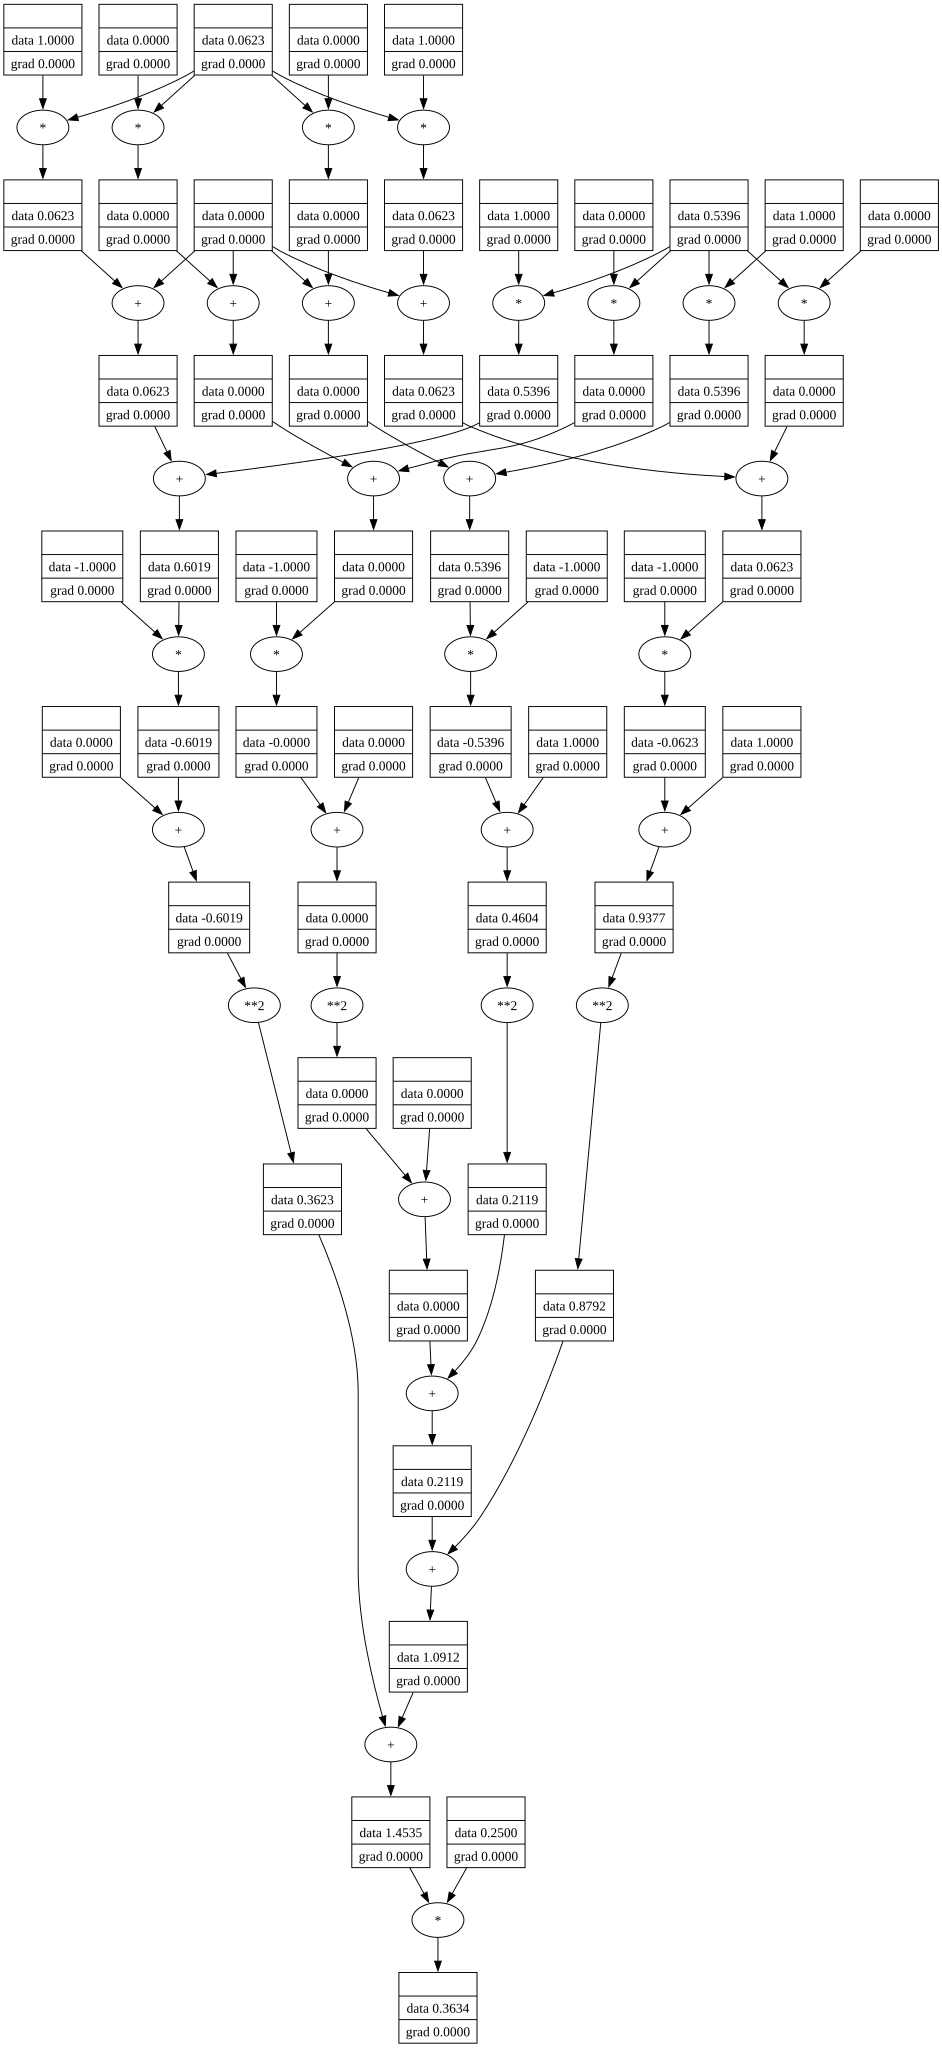

In [20]:
show_graph(loss, rankdir="TB",format="png")

In [21]:
#Zero
for p in Model.parameters():
    p.grad = 0.0
#Backward
loss.backward()

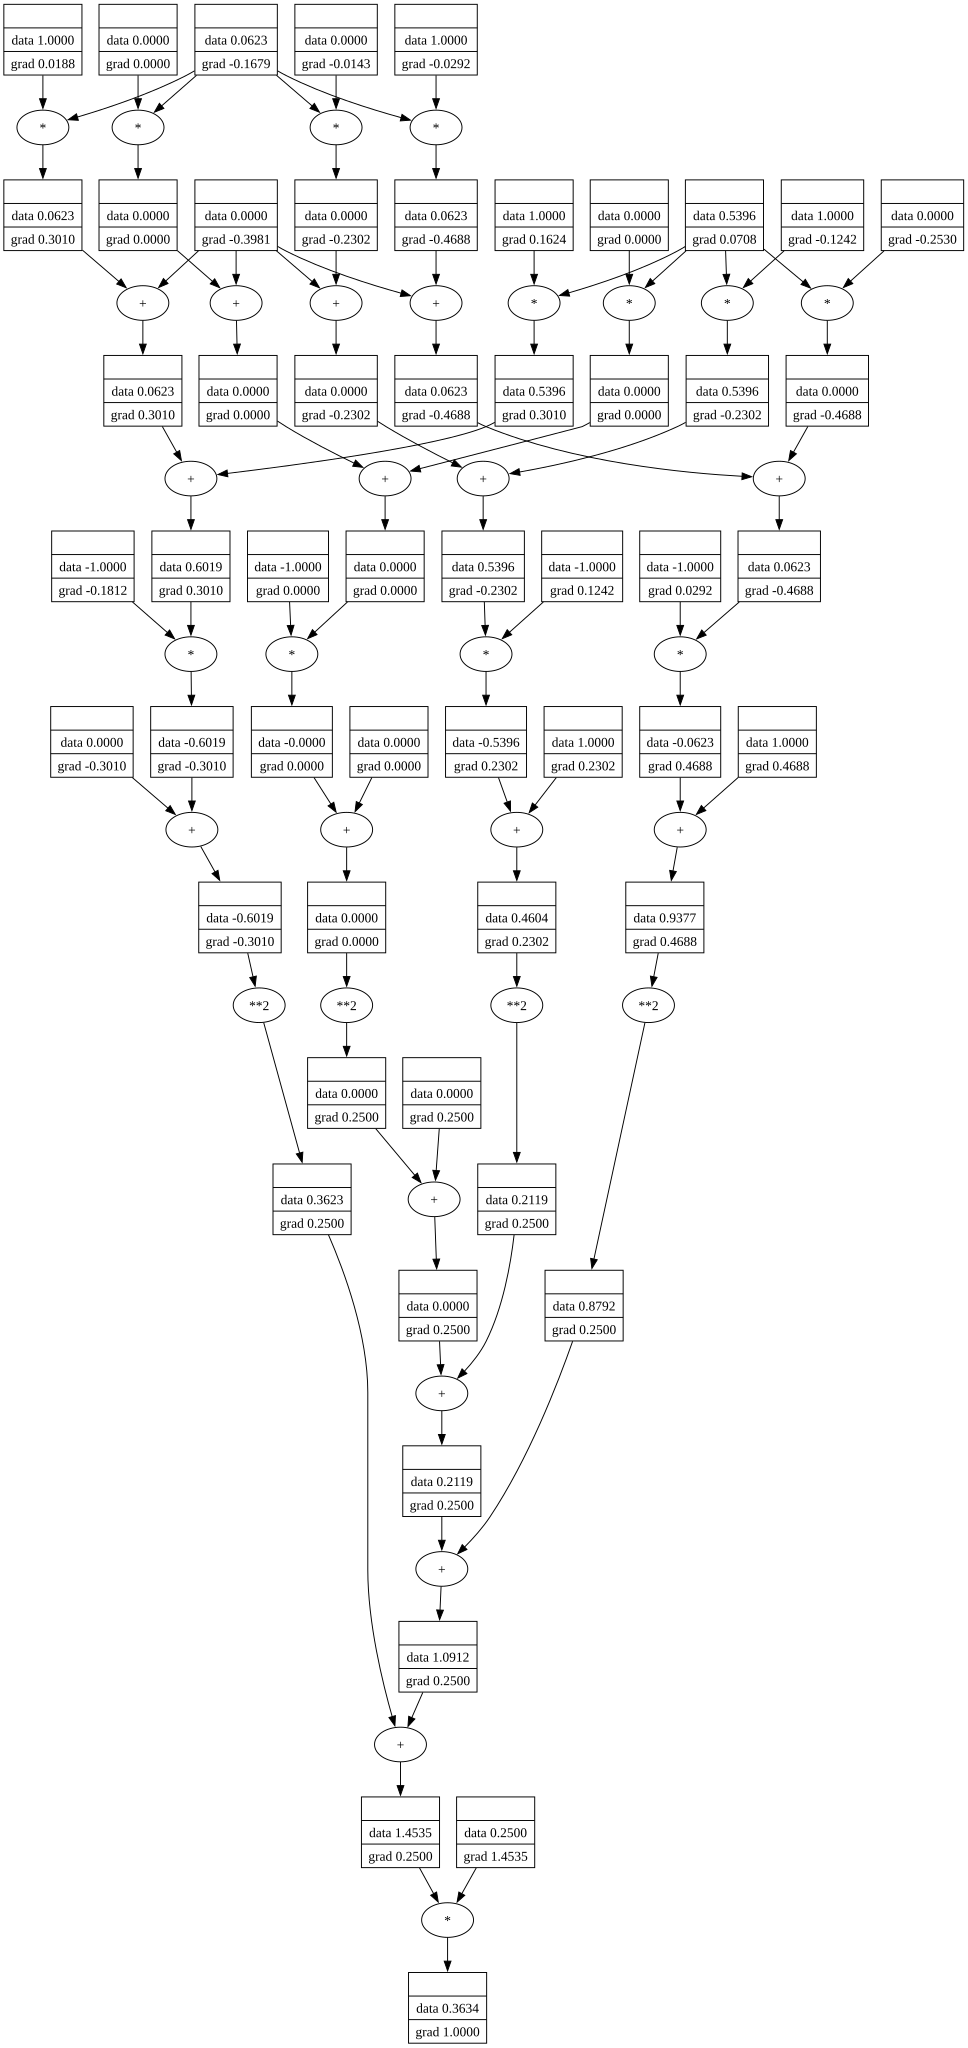

In [22]:
show_graph(loss, rankdir="TB",format="png")

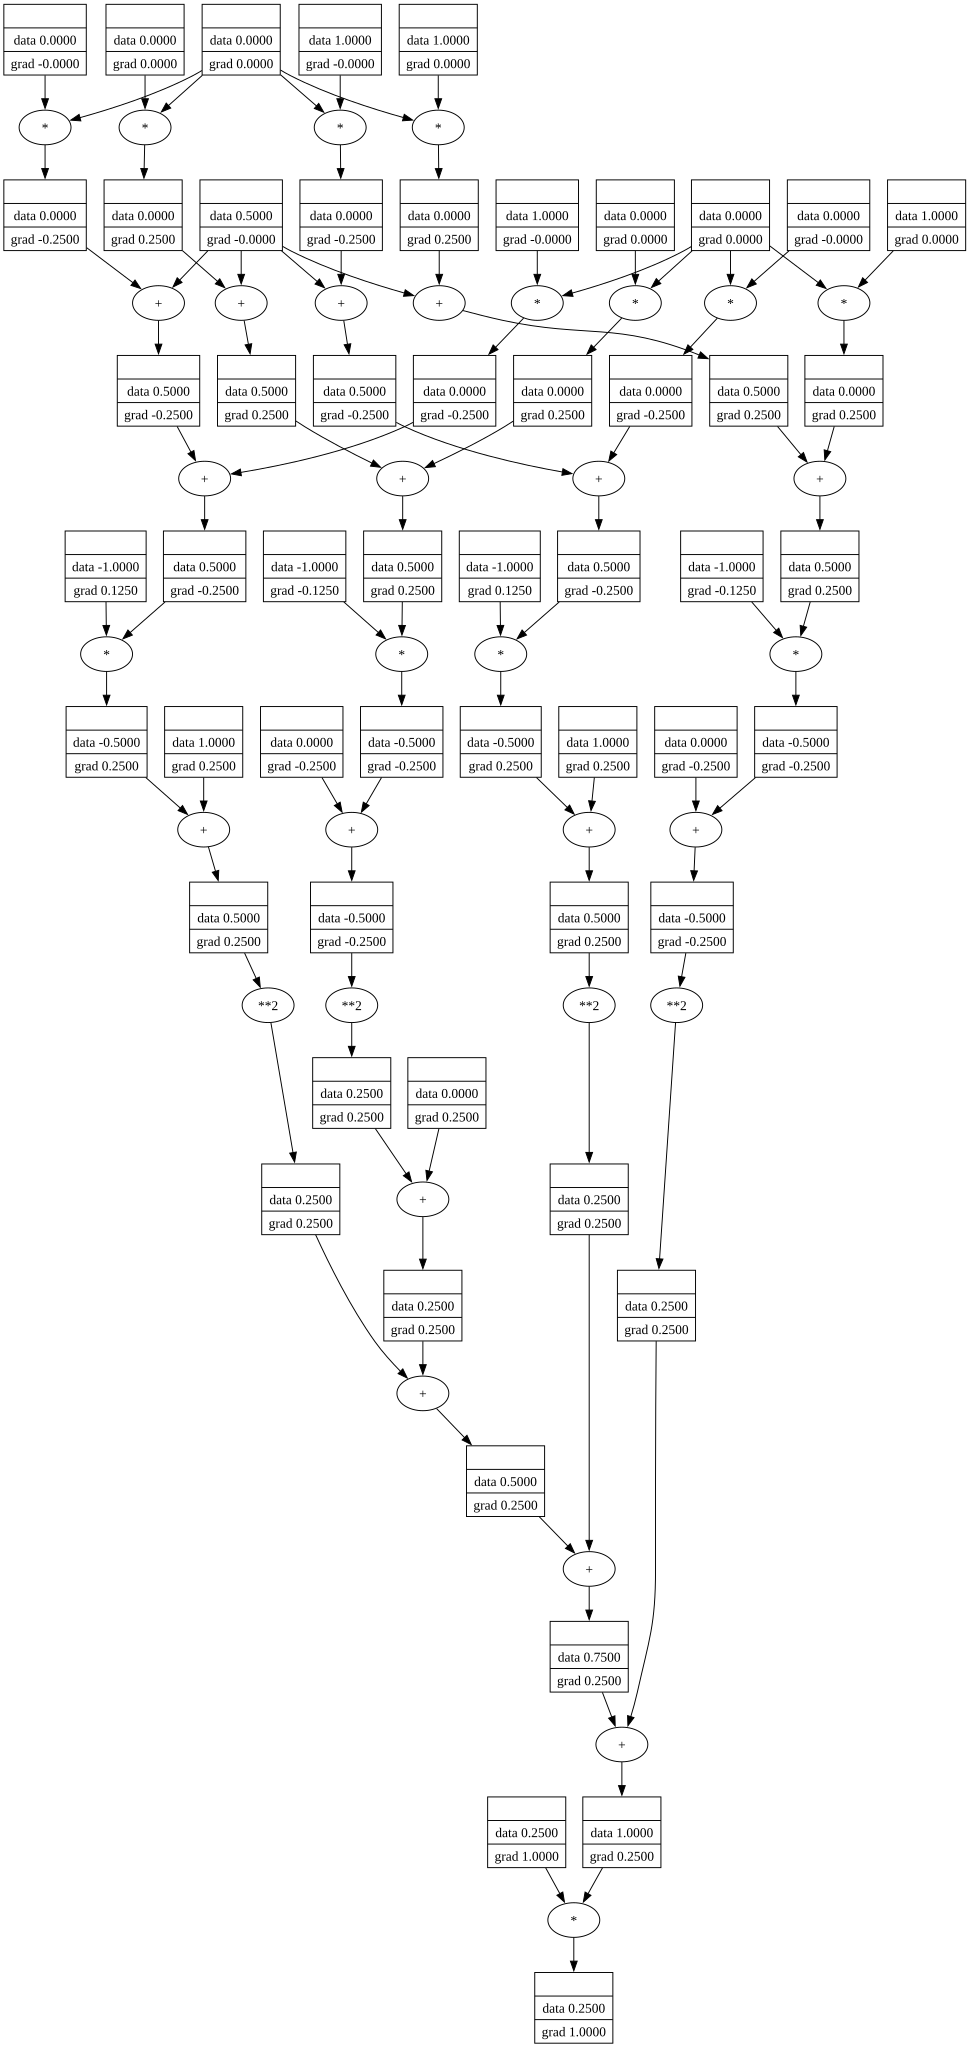

In [23]:
for p in Model.parameters():
    p.data -= p.grad * 0.01

for _ in range(10000):
    #Forward
    yhat = [Model(x)[0] for x in xs]
    #Loss
    loss = sum([(y - yh)**2 for y, yh in zip(ys, yhat)])/4
    #Zero
    for p in Model.parameters():
        p.grad = 0.0
    #Backward
    loss.backward()
    #Update
    for p in Model.parameters():
        p.data -= p.grad * 0.01
show_graph(loss, rankdir="TB",format="png")

In [24]:
Model([0, 0])

[Value(data=0.49999999999999045, grad=0, name=),
 Value(data=0.0, grad=0, name=)]

In [25]:
Model([0, 1])

[Value(data=0.49999999999999856, grad=0, name=),
 Value(data=0.06128621955564739, grad=0, name=)]

In [26]:
Model([1, 1])

[Value(data=0.5000000000000067, grad=0, name=),
 Value(data=-0.5427631189775757, grad=0, name=)]

In [27]:
print(loss)

Value(data=0.24999999999999997, grad=1, name=)
